## SETUP 

In [1]:
## SETUP

import subprocess, sys, os, importlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pca_main_functions
from sklearn.decomposition import PCA
importlib.reload(pca_main_functions)
from pca_obtain_energy_range import find_common_energy_range
from pca_interpolate_DOS import perform_interpolation


In [2]:
def overall_pca(base_dir, dataset):

    energy_ranges = [find_common_energy_range(base_dir), (-5.0, 5.0), (-10.0, 10.0)]

    # Initialize an empty list to store results
    results = []

    for range in energy_ranges:
        min_energy_global = range[0]
        max_energy_global = range[1]

        perform_interpolation(base_dir, min_energy_global, max_energy_global)

        interpolated_filepath = os.path.join(base_dir,'interpolated_dos.txt')

        molecule_names, dos_data = pca_main_functions.load_interpolated_dos(interpolated_filepath)
        
        np.savetxt('molecule_names.txt', molecule_names, fmt='%s')

        energy_values = dos_data.iloc[0,1:]
        dos_samples = dos_data.iloc[1:,:]
        pca, scaled_data = pca_main_functions.perform_PCA(dos_samples)

        explained_variance = pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance)

        thresholds = [0.80, 0.90]

        for threshold in thresholds:
            n_pc = np.argmax(cumulative_variance >= threshold) + 1
            pca_main_functions.transform_data_to_pc(dataset, molecule_names, scaled_data, min_energy_global, max_energy_global, threshold, n_pc)

            # Store the results for this energy range and threshold
            results.append({
                'dataset': dataset,
                'energy_range': f'({min_energy_global:.2f}, {max_energy_global:.2f})',
                'cum_variance': threshold,  # Cumulative variance at the end
                'n_pc': n_pc
            })

    # Convert the results list to a pandas DataFrame
    results_df = pd.DataFrame(results)

    return results_df

In [3]:
# Create an empty DataFrame
overall_results = pd.DataFrame(columns=['dataset',
                                        'energy_range',
                                        'cum_variance',
                                        'n_pc'], dtype='float64')

overall_results

,dataset,energy_range,cum_variance,n_pc


In [4]:
base_dir = os.path.dirname(os.getcwd())

doscar_files_dirs = [f for f in os.listdir(base_dir) if f.startswith('DOSCAR_files')]

for dir in doscar_files_dirs:
    print(f"Processing directory is {dir}")
    dir_path = os.path.join(base_dir, dir)
    cur_results = overall_pca(dir_path, dir)
    overall_results = pd.concat([overall_results, cur_results], ignore_index=True).drop_duplicates()

overall_results


Processing directory is DOSCAR_files_1st_Initial
Interpolated DOS data saved to c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\DOSCAR_files_1st_Initial\interpolated_dos.txt


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)


Interpolated DOS data saved to c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\DOSCAR_files_1st_Initial\interpolated_dos.txt


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)


Interpolated DOS data saved to c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\DOSCAR_files_1st_Initial\interpolated_dos.txt
Processing directory is DOSCAR_files_2nd_Extended


...

Interpolated DOS data saved to c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\DOSCAR_files_2nd_Extended\interpolated_dos.txt


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)


Interpolated DOS data saved to c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\DOSCAR_files_2nd_Extended\interpolated_dos.txt


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)


,dataset,energy_range,cum_variance,n_pc
0,DOSCAR_files_1st_Initial,"(-11.44, 4.12)",0.8,13.0
1,DOSCAR_files_1st_Initial,"(-11.44, 4.12)",0.9,24.0
2,DOSCAR_files_1st_Initial,"(-5.00, 5.00)",0.8,8.0
3,DOSCAR_files_1st_Initial,"(-5.00, 5.00)",0.9,15.0
4,DOSCAR_files_1st_Initial,"(-10.00, 10.00)",0.8,11.0
5,DOSCAR_files_1st_Initial,"(-10.00, 10.00)",0.9,22.0
6,DOSCAR_files_2nd_Extended,"(-1.46, 3.27)",0.8,10.0
7,DOSCAR_files_2nd_Extended,"(-1.46, 3.27)",0.9,14.0
8,DOSCAR_files_2nd_Extended,"(-5.00, 5.00)",0.8,25.0
9,DOSCAR_files_2nd_Extended,"(-5.00, 5.00)",0.9,36.0


In [5]:
# Create a combined 'hue_style' column to combine both cum_variance and energy_range
overall_results['hue_style'] = 'Variance: ' + overall_results['cum_variance'].astype(str) + ' \n Energy range: ' + overall_results['energy_range'].astype(str)

overall_results

,dataset,energy_range,cum_variance,n_pc,hue_style
0,DOSCAR_files_1st_Initial,"(-11.44, 4.12)",0.8,13.0,"Variance: 0.8 \n Energy range: (-11.44, 4.12)"
1,DOSCAR_files_1st_Initial,"(-11.44, 4.12)",0.9,24.0,"Variance: 0.9 \n Energy range: (-11.44, 4.12)"
2,DOSCAR_files_1st_Initial,"(-5.00, 5.00)",0.8,8.0,"Variance: 0.8 \n Energy range: (-5.00, 5.00)"
3,DOSCAR_files_1st_Initial,"(-5.00, 5.00)",0.9,15.0,"Variance: 0.9 \n Energy range: (-5.00, 5.00)"
4,DOSCAR_files_1st_Initial,"(-10.00, 10.00)",0.8,11.0,"Variance: 0.8 \n Energy range: (-10.00, 10.00)"
5,DOSCAR_files_1st_Initial,"(-10.00, 10.00)",0.9,22.0,"Variance: 0.9 \n Energy range: (-10.00, 10.00)"
6,DOSCAR_files_2nd_Extended,"(-1.46, 3.27)",0.8,10.0,"Variance: 0.8 \n Energy range: (-1.46, 3.27)"
7,DOSCAR_files_2nd_Extended,"(-1.46, 3.27)",0.9,14.0,"Variance: 0.9 \n Energy range: (-1.46, 3.27)"
8,DOSCAR_files_2nd_Extended,"(-5.00, 5.00)",0.8,25.0,"Variance: 0.8 \n Energy range: (-5.00, 5.00)"
9,DOSCAR_files_2nd_Extended,"(-5.00, 5.00)",0.9,36.0,"Variance: 0.9 \n Energy range: (-5.00, 5.00)"


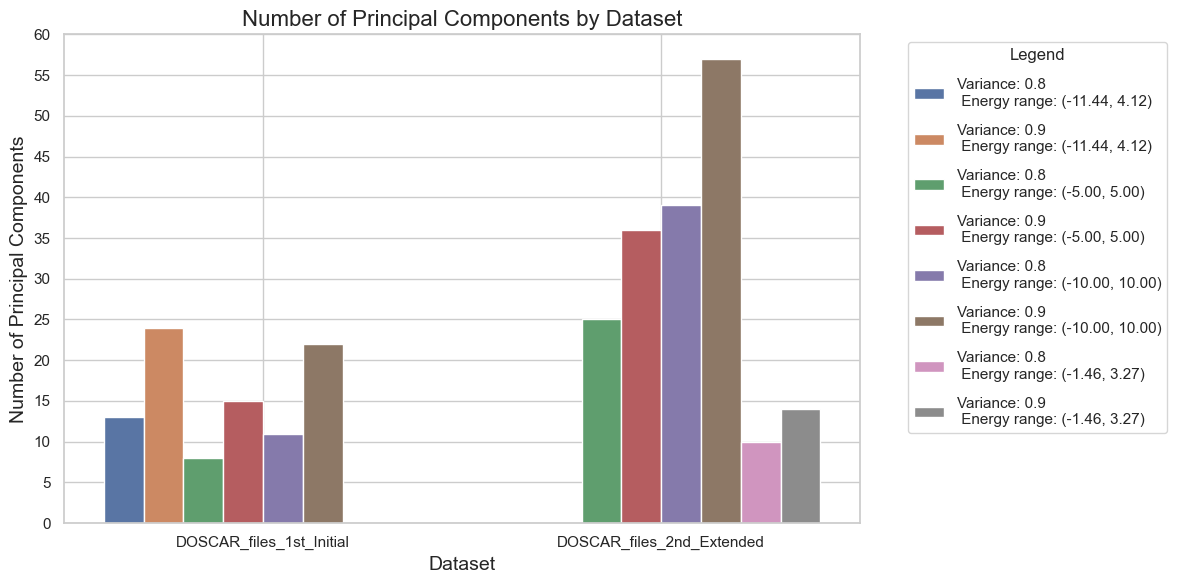

c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


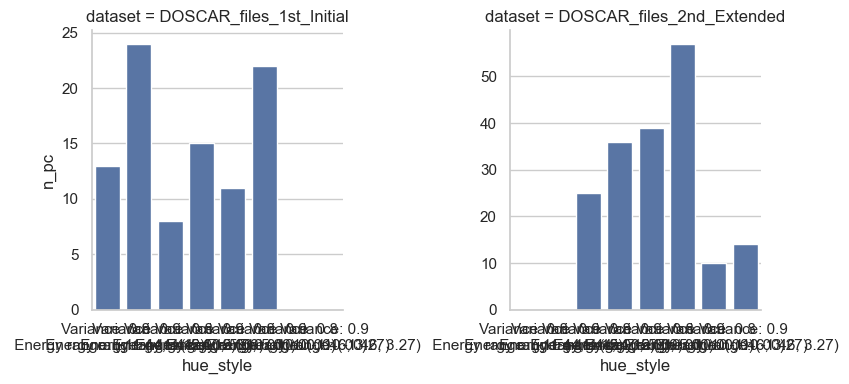

In [6]:
# Create a combined 'hue_style' column to combine both cum_variance and energy_range
overall_results['hue_style'] = 'Variance: ' + overall_results['cum_variance'].astype(str) + ' \n Energy range: ' + overall_results['energy_range'].astype(str)

# Set the style for the plot
sns.set(style="whitegrid")

# Create a scatter plot
plt.figure(figsize=(12, 6))
# sns.scatterplot(data=overall_results, x='dataset', y='n_pc', hue='hue_style', style='hue_style', s=100)
sns.barplot(data=overall_results, x='dataset', y='n_pc', hue='hue_style', dodge=True)

# Add titles and labels
plt.title('Number of Principal Components by Dataset', fontsize=16)
plt.xlabel('Dataset', fontsize=14)
plt.ylabel('Number of Principal Components', fontsize=14)
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), labelspacing=1.0, loc='upper left')
plt.grid(True)

# Adjust y-axis ticks if necessary
plt.yticks(range(0, int(overall_results['n_pc'].max()) + 5, 5))

# Show the plot
plt.tight_layout()
plt.show()

# Create a FacetGrid for separate bar plots by dataset
g = sns.FacetGrid(overall_results, col="dataset", col_wrap=3, height=4, sharey=False)

# Map barplot to each subplot
g.map(
    sns.barplot,
    "hue_style",
    "n_pc",
    order=None,  # Let it adjust based on the unique energy ranges
    ci=None  # Remove error bars if not needed
)


## FOR 1ST DATA SET

In [ ]:
base_dir=os.path.join(os.path.dirname(os.getcwd()), 'DOSCAR_files_1')

print(f"The base directory is {base_dir}")
cur_results = overall_pca(base_dir, 'set_1')
cur_results

## FOR DATASET 1&2

In [ ]:
base_dir=os.path.join(os.path.dirname(os.getcwd()), 'DOSCAR_files_1-2')

print(f"The base directory is {base_dir}")
cur_results = overall_pca(base_dir, 'set_1-2')
cur_results

## FOR DATASET 1&2&3

In [ ]:
base_dir=os.path.join(os.path.dirname(os.getcwd()), 'DOSCAR_files_1-3')

print(f"The base directory is {base_dir}")
cur_results = overall_pca(base_dir, 'set_1-3')
cur_results

## FOR DATASET 1&2&3&4

In [ ]:
base_dir=os.path.join(os.path.dirname(os.getcwd()), 'DOSCAR_files_1-4')

print(f"The base directory is {base_dir}")
cur_results = overall_pca(base_dir, 'set_1-4')
cur_results

## FOR DATASET 1&2&3&4&5

In [8]:
base_dir=os.path.join(os.path.dirname(os.getcwd()), 'DOSCAR_files_2nd_Extended')

print(f"The base directory is {base_dir}")
cur_results = overall_pca(base_dir, 'set_1-5')
cur_results

The base directory is c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\DOSCAR_files_2nd_Extended
Interpolated DOS data saved to c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\DOSCAR_files_2nd_Extended\interpolated_dos.txt


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)


Interpolated DOS data saved to c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\DOSCAR_files_2nd_Extended\interpolated_dos.txt


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)


Interpolated DOS data saved to c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\DOSCAR_files_2nd_Extended\interpolated_dos.txt


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)


,dataset,energy_range,cum_variance,n_pc
0,set_1-5,"(-1.46, 3.27)",0.8,10
1,set_1-5,"(-1.46, 3.27)",0.9,14
2,set_1-5,"(-5.00, 5.00)",0.8,25
3,set_1-5,"(-5.00, 5.00)",0.9,36
4,set_1-5,"(-10.00, 10.00)",0.8,39
5,set_1-5,"(-10.00, 10.00)",0.9,57
